<a href="https://colab.research.google.com/github/Akash-Behera-123/DL-BasicProject/blob/main/DL3_MNIST_DigitClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**MNIST Handwritten Digit Classification Deep Learning**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from tensorflow.math import confusion_matrix

Loading mnist data from keras

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [ ]:
type(x_train)

numpy.ndarray

In [ ]:
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Training data = 60,000 images
test data =10,000 images


dimension 28x28
type= Grayscale image channel 1

In [ ]:
print(x_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [ ]:
print(x_train[10].shape)

(28, 28)


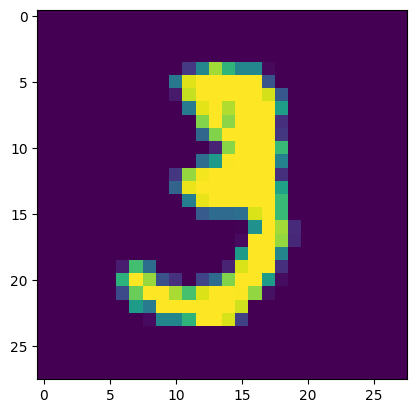

3


In [ ]:
# displaying image

plt.imshow(x_train[10])
plt.show()

#print the corresponding label
print(y_train[10])

In [ ]:
print(y_train.shape,y_test.shape)

(60000,) (10000,)


In [ ]:
#unique values in y train
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [ ]:
#unique values in y test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]


we can use these labels as such or we also apply One Hot Encoding

All image have the same dimension in the dataset if not we have to resize the images to a commom dimension

In [ ]:
#scaling the values

x_train = x_train/255
x_test=x_test/255



In [ ]:
print(x_train[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

#Building the Neural Network

In [ ]:
#setting up the layers of the Neural Network

model= keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                         keras.layers.Dense(50,activation='relu'),
                         keras.layers.Dense(50,activation='relu'),
                         keras.layers.Dense(10,activation='sigmoid'),
                         ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compiling  the Neural network

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#training the neural network

model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9122 - loss: 0.3016
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9578 - loss: 0.1406
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9688 - loss: 0.1029
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9754 - loss: 0.0820
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9793 - loss: 0.0679
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9828 - loss: 0.0576
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9857 - loss: 0.0484
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9873 - loss: 0.0421
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9884 - loss: 0.0370
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9897 - loss: 0.0341


Training data accuracy =99%

**Accuracy on test data**

In [ ]:
loss,accuracy = model.evaluate(x_test,y_test)
print(accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9675 - loss: 0.1240
0.9674999713897705


test data accuracy =96.9%


In [ ]:
print(x_test.shape)

(10000, 28, 28)


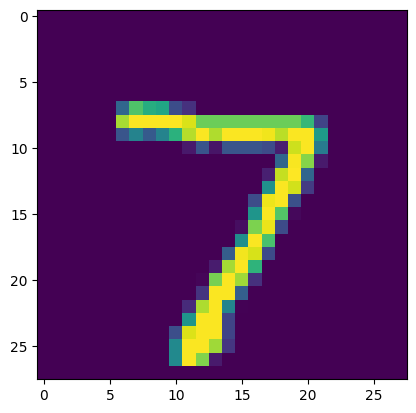

In [ ]:
#first data point in x_test
plt.imshow(x_test[0])
plt.show()

In [ ]:
print(y_test[0])

7


In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print(y_pred.shape)

(10000, 10)


In [ ]:
print(y_pred[0])

[1.1548245e-03 2.7940481e-04 6.0998186e-02 9.4434309e-01 1.7786531e-09
 7.6138914e-02 9.1247197e-11 9.9999738e-01 1.6420345e-01 6.7096680e-01]


model.predict gives the prediction probability of each class for the data point

In [ ]:
#converting the prediction probability to class label

label_for_first_img = np.argmax(y_pred[0])
print(label_for_first_img)

7


In [ ]:
#converting the prediction probability to class for al test data points
y_pred_labels =[np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

In [ ]:
print(y_pred)

[[1.1548245e-03 2.7940481e-04 6.0998186e-02 ... 9.9999738e-01
  1.6420345e-01 6.7096680e-01]
 [5.3777611e-03 7.5626785e-01 1.0000000e+00 ... 3.1578632e-13
  1.0850242e-01 3.1391331e-13]
 [5.3021207e-04 9.9684381e-01 1.7140527e-01 ... 1.5775852e-01
  3.9382580e-01 1.9177809e-02]
 ...
 [3.3740893e-05 5.4809720e-05 5.8843625e-06 ... 2.2586826e-02
  3.1387776e-02 9.2068249e-01]
 [4.2061056e-06 1.4269599e-06 5.6178226e-07 ... 1.3070468e-06
  9.7760731e-01 1.6196876e-05]
 [1.8958687e-07 2.7361079e-03 1.2976762e-04 ... 1.3312929e-10
  2.5139470e-05 5.4827242e-06]]


Confusion matrix

In [ ]:
conf_mat= confusion_matrix(y_test,y_pred_labels)

In [ ]:
print(conf_mat)

tf.Tensor(
[[ 934    0   15    3    3    1    5    1    2   16]
 [   2 1097    2    4    1    1    4    1   23    0]
 [   3    0 1007    2    2    0    1    5   12    0]
 [   0    0    7  974    1    9    2    4    9    4]
 [   0    0    3    0  963    0    5    1    3    7]
 [   1    0    2   18    3  848    6    2   11    1]
 [   5    1    2    0    3   11  930    1    2    3]
 [   0    1   10    4    1    0    0  999    2   11]
 [   1    0    6    6    5    2    1    4  945    4]
 [   0    2    0    2   16    4    0    1    6  978]], shape=(10, 10), dtype=int32)


Text(0.5, 47.7222222222222, 'predicted label')

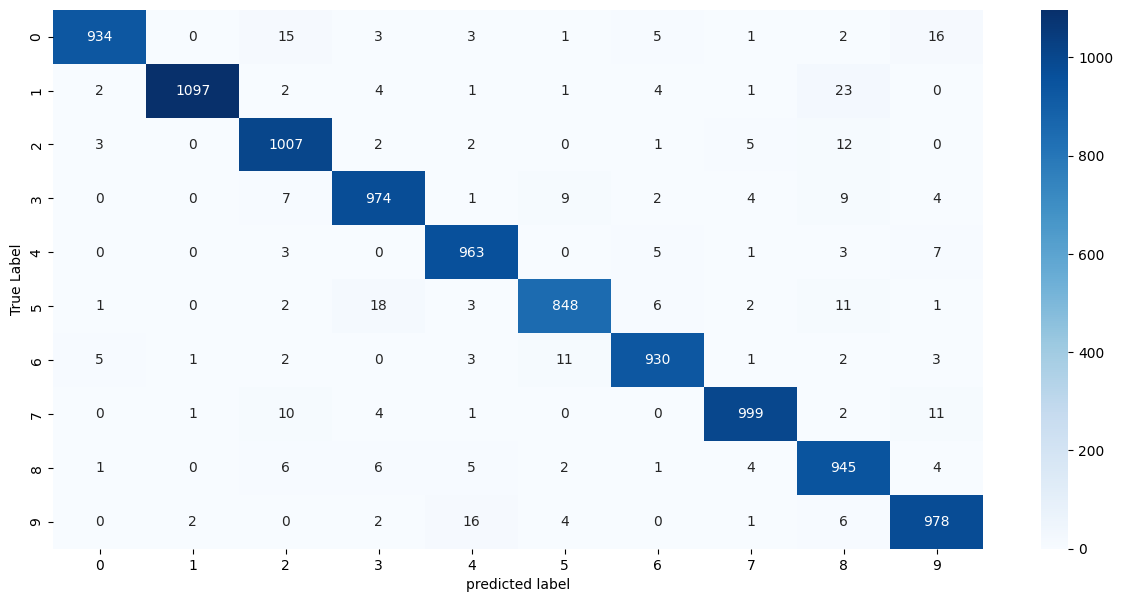

In [ ]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('predicted label')

#**Predictive System**

In [ ]:
import urllib.request

input_image_path = input('Path of the image to be predicted (can be a local path or a URL)')

if input_image_path.startswith('http://') or input_image_path.startswith('https://'):
    # Download the image from the URL
    try:
        response = urllib.request.urlopen(input_image_path)
        image_array = np.asarray(bytearray(response.read()), dtype=np.uint8)
        input_image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    except Exception as e:
        print(f"Error downloading or decoding image from URL: {e}")
        input_image = None
else:
    # Read local image file
    input_image = cv2.imread(input_image_path)

if input_image is None:
    print("Error: Could not load the image. Please check the path or URL.")
else:
    cv2_imshow(input_image)

    grayscale = cv2.cvtColor(input_image,cv2.COLOR_RGB2BGRAY)

    input_image_resize = cv2.resize(grayscale,(28,28))

    input_image_resize = input_image_resize/255

    image_reshaped = np.reshape(input_image_resize, [1,28,28])

    input_prediction = model.predict(image_reshaped)

    input_pred_label = np.argmax(input_prediction)

    print('The Handwritten Digit is recognised as ',input_pred_label)